# Lab 7.01 - Time series analysis

In [1]:
# Package imports for data science and time series analysis in particular
import numpy as np                                  # "Scientific computing"
import pandas as pd                                 # Dataframe
import scipy.stats as stats                         # Statistical tests

import matplotlib.pyplot as plt                     # Basic visualisation
import seaborn as sns                               # Advanced dataviz

from sklearn.linear_model import LinearRegression   # Linear regression model

# Time series analysis
from datetime import datetime
from sklearn.metrics import mean_absolute_error,mean_squared_error
from statsmodels.tsa.api import Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose

### Exercise 1 - House sales

The file House Sales.csv contains monthly data on the number of new one-family
houses sold in the United States (in thousands) from January 1991 through December 2011.
Housing sales were steadily trending upward until about the beginning of 2006, then the
bottom fell out of the housing market, and sales eventually started trending upward again.   

- First Create a time series chart of the data.
- Add predictions for Simple Moving Average with span of 3, 6 and 12 months to the dataframe.
- Add predictions for Simple Exponential Smooting to the dataframe.
- Add predictions for Double Exponential Smoothing to the dataframe.
- Calculate the MAE to find the best model

In [2]:
data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Monthly%20House%20Sales.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])
data.head()

/tmp/ipykernel_2182/2792024889.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('https://raw.githubusercontent.com/HoGentTIN/dsai-labs/main/data/Monthly%20House%20Sales.csv', delimiter = ";", parse_dates=['Month']).set_index(['Month'])


,Houses Sold
Month,
jan/91,401
feb/91,482
mrt/91,507
apr/91,508
mei/91,517


First Create a time series chart of the data.

<Axes: xlabel='Month'>

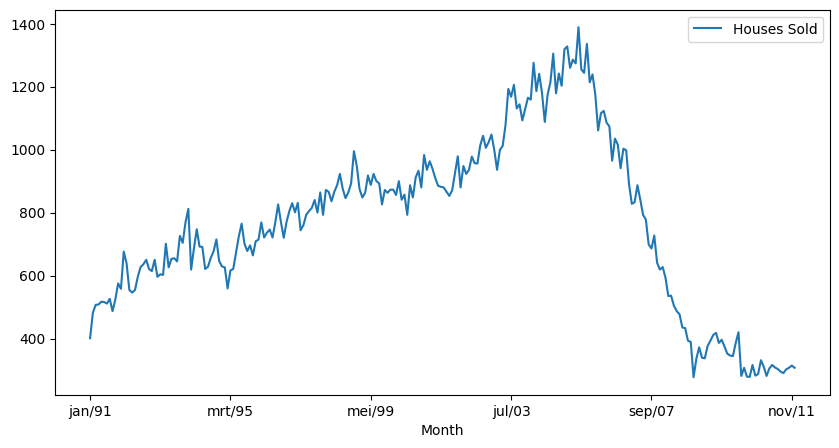

In [3]:
data.plot(y='Houses Sold', figsize=[10,5])

Add predictions for Simple Moving Average with span of 3, 6 and 12 months to the dataframe.

In [4]:
data['SMA3'] = data['Houses Sold'].rolling(3).mean().shift(1)
data['SMA6'] = data['Houses Sold'].rolling(6).mean().shift(1)
data['SMA12'] = data['Houses Sold'].rolling(12).mean().shift(1)

data.head()

,Houses Sold,SMA3,SMA6,SMA12
Month,,,,
jan/91,401,NaN,NaN,NaN
feb/91,482,NaN,NaN,NaN
mrt/91,507,NaN,NaN,NaN
apr/91,508,463.333333,NaN,NaN
mei/91,517,499.000000,NaN,NaN


Add predictions for Simple Exponential Smooting to the dataframe.

In [ ]:
#trainingsdata: tot 2009
#testdata: vanaf 2010
#werkt enkel als datum is source gesteld is als index (bv: ...set_index(['Month'])

train = data['Houses Sold'][:'dec/09']
test = data['Houses Sold']['jan/10':]

In [ ]:
#Template code voor SES - NIET HET ANTWOORD
# We use the library statsmodels!
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Train the model
data_ses = SimpleExpSmoothing(wounded_data['number_of_heavily_wounded']).fit(
    smoothing_level=0.1,
    optimized=False
)

# Add fitted values to the dataframe
wounded_data['SES'] = data_ses.level

wounded_data.head()

In [ ]:
#Antwoord:

from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# Simple Exponential Smoothing
data_ses = SimpleExpSmoothing(train).fit()
ses_fcast = data_ses.forecast(24) #voorspel komende twee jaar

Add predictions for Double Exponential Smoothing to the dataframe.

In [20]:
#Antwoord:

# Double Exponential Smoothing
data_des = Holt(train).fit()
des_fcast = data_des.forecast(24) #voorspel komende twee jaar

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a sup

Calculate the MAE to find the best model. First drop the rows with NaN.

In [14]:
#MAE berekenen voor beide modellen
#opmerking: MAE berekenen voor SES is onorthodox - is niet zo accuraat

#Simple Moving Average 3 | SMA3
y_true = test.values
y_predicted = data['SMA3'][-24:].values

print(f'MAE SMA3 = {mean_absolute_error(y_true, y_predicted)}')

MAE SMA3 = 23.944444444444443


In [16]:
#Simple Exponential Smoothing
y_true = test.values
y_predicted = data_ses.forecast(24).values

print(f'MAE SES = {mean_absolute_error(y_true, y_predicted)}')

MAE SES = 55.83416417041343


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [21]:
#Double Exponential Smoothing
y_true = test.values
y_predicted = data_des.forecast(24).values

print(f'MAE DES = {mean_absolute_error(y_true, y_predicted)}')

MAE DES = 35.27314556185897


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
columns = ['SMA3', 'SMA6', 'SMA12', 'SES', 'DES']

## Source
Business Analytics Data Analysis & Decision Making